# TrashNet — Clasificador jerárquico por contenedor con MobileNetV3Small + Optuna (PyTorch)

Tercer modelo del proyecto. Mismo dataset TrashNet y mismo backbone que el modelo de
6 clases, pero **las 6 clases originales se reasignan a 4 destinos de contenedor**:

| Material original | Contenedor |
|---|---|
| plastic + metal | **amarillo** |
| paper + cardboard | **azul** |
| trash | **gris** |
| glass | **verde** |

No hace falta duplicar ni mover imágenes: la reasignación se hace en código con el
`target_transform` de `ImageFolder`.

Estructura:

- **Parte A** — modelo con hiperparámetros manuales (el baseline a batir);
- **Parte B** — búsqueda de hiperparámetros con Optuna y selección del mejor modelo;
- **Parte C** — evaluación y comparación en test (accuracy, precision, recall, F1,
  matrices de confusión, curvas ROC y predicciones de ejemplo).

El modelo y el protocolo de entrenamiento son los del notebook equivalente en
TensorFlow (`tensorflow/TrashNet_TensorFlow_Jerarquico_DEFINITIVO.ipynb`). La **Parte B
sí se aparta a propósito** de esa réplica: la búsqueda de allí tiene tres problemas
metodológicos que aquí están corregidos, y están explicados en la cabecera de la Parte B.

Las métricas están implementadas a mano con NumPy porque el entorno no tiene
scikit-learn (ver `../CONTEXT.md`, §5).

> **Antes de ejecutar:** cerrar cualquier kernel de TensorFlow abierto. TF reserva casi
> toda la VRAM de la GPU al arrancar y PyTorch se queda sin memoria.
>
> **Tiempo estimado en GPU (GTX 1650 SUPER): ~1 hora.** Parte A ~6 min, búsqueda de 30
> trials ~35 min, reentrenamiento del top-3 ~15 min.

In [34]:
import sys; print(sys.executable)

/home/benjamin-sanchez/miniconda3/envs/frameworks-ia/bin/python


In [35]:
# 1. Importaciones y configuración general

import os
import gc
import copy
import time
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

import optuna

SEED = 42

# Generador propio del DataLoader: se reinicia dentro de semilla() para que el orden
# del shuffle sea el mismo en cada trial y los trials sean comparables entre sí.
generador = torch.Generator()


def semilla(valor=SEED):
    """
    Reinicia TODAS las fuentes de aleatoriedad del entrenamiento.

    Se llama al inicio de cada trial de Optuna y de cada reentrenamiento. Sin esto los
    trials arrastran el estado del RNG del anterior, así que la misma configuración da
    resultados distintos según en qué posición de la búsqueda le toque correr — y esa
    varianza se confunde con diferencias reales entre hiperparámetros.
    """
    random.seed(valor)
    np.random.seed(valor)
    torch.manual_seed(valor)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(valor)
    generador.manual_seed(valor)


semilla()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_FASE1 = 25
EPOCHS_FASE2 = 15
FINE_TUNE_LR = 1e-5

# Búsqueda con Optuna
#
# OPTUNA_TRIALS > OPTUNA_STARTUP_TRIALS es OBLIGATORIO para que TPE haga algo: los
# primeros `n_startup_trials` se muestrean al azar de la distribución previa y solo
# después el sampler construye su modelo. Con 10 trials y el default de 10 startup, la
# búsqueda es random search puro y el TPE nunca se usa.
OPTUNA_TRIALS = 30
OPTUNA_STARTUP_TRIALS = 10
OPTUNA_EPOCHS = 8

# Cuántos de los mejores trials se reentrenan a presupuesto completo para elegir
TOP_K = 3

# 0 evita problemas con el multiprocessing dentro de Jupyter; súbelo a 2-4 si va lento
NUM_WORKERS = 0

# Este notebook vive en PyTorch/jerarquico/, así que el dataset queda dos niveles arriba
BASE_DIR = "../../dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "validation")
TEST_DIR = os.path.join(BASE_DIR, "test")

# Clases originales de TrashNet (orden alfabético, el que usa ImageFolder)
ORIGINAL_CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

# Clases finales del modelo jerárquico (también alfabéticas, igual que en TensorFlow)
CLASSES = ["amarillo", "azul", "gris", "verde"]
N_CLASSES = len(CLASSES)

# Mapeo por nombre y su versión por índice:
# cardboard(0)->azul(1), glass(1)->verde(3), metal(2)->amarillo(0),
# paper(3)->azul(1), plastic(4)->amarillo(0), trash(5)->gris(2)
MAPEO_NOMBRE = {
    "cardboard": "azul",
    "glass": "verde",
    "metal": "amarillo",
    "paper": "azul",
    "plastic": "amarillo",
    "trash": "gris"
}

ORIGINAL_TO_CONTAINER = [
    CLASSES.index(MAPEO_NOMBRE[clase]) for clase in ORIGINAL_CLASSES
]

# Normalización estándar de ImageNet, la que espera el backbone preentrenado
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Salidas propias de este modelo, separadas de las del modelo de 6 clases
MODEL_DIR = "modelos"
RESULTS_DIR = "predicciones"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("PyTorch:", torch.__version__)
print("Optuna:", optuna.__version__)
print("Dispositivo:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU detectada:", torch.cuda.get_device_name(0))
else:
    print("GPU detectada: No; se utilizará CPU (el entrenamiento será lento)")

print("\nClases finales:", CLASSES)
print("Mapeo índice original -> índice contenedor:", ORIGINAL_TO_CONTAINER)

PyTorch: 2.12.1+cu126
Optuna: 4.9.0
Dispositivo: cuda
GPU detectada: NVIDIA GeForce GTX 1650 SUPER

Clases finales: ['amarillo', 'azul', 'gris', 'verde']
Mapeo índice original -> índice contenedor: [1, 3, 0, 1, 0, 2]


In [36]:
# 2. Validación de la estructura del dataset original
#    Las carpetas siguen siendo las de los 6 materiales: el reagrupamiento es en código.

def validar_directorio_dataset(ruta, nombre):
    if not os.path.isdir(ruta):
        raise FileNotFoundError(
            f"No existe el directorio {nombre}: {ruta}"
        )

    clases_encontradas = sorted(
        carpeta for carpeta in os.listdir(ruta)
        if os.path.isdir(os.path.join(ruta, carpeta))
    )

    faltantes = sorted(set(ORIGINAL_CLASSES) - set(clases_encontradas))
    if faltantes:
        raise ValueError(
            f"Faltan clases en {nombre}: {faltantes}"
        )

    print(f"{nombre}: {clases_encontradas}")

validar_directorio_dataset(TRAIN_DIR, "Train")
validar_directorio_dataset(VALID_DIR, "Validation")
validar_directorio_dataset(TEST_DIR, "Test")

Train: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Validation: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Test: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [37]:
# 3. Conteo de imágenes por clase original y por contenedor
#    (sin pandas: se imprimen las tablas a mano)

def contar_imagenes_por_clase(ruta):
    extensiones = (".jpg", ".jpeg", ".png", ".webp")
    conteo = {}

    for clase in ORIGINAL_CLASSES:
        carpeta = os.path.join(ruta, clase)
        conteo[clase] = sum(
            archivo.lower().endswith(extensiones)
            for archivo in os.listdir(carpeta)
        )

    return conteo


def reagrupar_conteos(conteos_originales):
    agrupados = {clase: 0 for clase in CLASSES}

    for clase_original, cantidad in conteos_originales.items():
        agrupados[MAPEO_NOMBRE[clase_original]] += cantidad

    return agrupados


train_count_original = contar_imagenes_por_clase(TRAIN_DIR)
valid_count_original = contar_imagenes_por_clase(VALID_DIR)
test_count_original = contar_imagenes_por_clase(TEST_DIR)

train_count = reagrupar_conteos(train_count_original)
valid_count = reagrupar_conteos(valid_count_original)
test_count = reagrupar_conteos(test_count_original)

print("CONTEO POR MATERIAL ORIGINAL")
print(f"{'clase':<12}{'train':>8}{'validation':>13}{'test':>8}")
for clase in ORIGINAL_CLASSES:
    print(
        f"{clase:<12}"
        f"{train_count_original[clase]:>8}"
        f"{valid_count_original[clase]:>13}"
        f"{test_count_original[clase]:>8}"
    )

print("\nCONTEO POR CONTENEDOR")
print(f"{'clase':<12}{'train':>8}{'validation':>13}{'test':>8}")
for clase in CLASSES:
    print(
        f"{clase:<12}"
        f"{train_count[clase]:>8}"
        f"{valid_count[clase]:>13}"
        f"{test_count[clase]:>8}"
    )

print("\nTotales:")
print(
    f"{'':<12}"
    f"{sum(train_count.values()):>8}"
    f"{sum(valid_count.values()):>13}"
    f"{sum(test_count.values()):>8}"
)

print("\nMapeo utilizado:")
for origen, destino in MAPEO_NOMBRE.items():
    print(f"{origen:<10} -> {destino}")

CONTEO POR MATERIAL ORIGINAL
clase          train   validation    test
cardboard        282           60      61
glass            350           75      76
metal            287           61      62
paper            415           89      90
plastic          337           72      73
trash             95           20      22

CONTEO POR CONTENEDOR
clase          train   validation    test
amarillo         624          133     135
azul             697          149     151
gris              95           20      22
verde            350           75      76

Totales:
                1766          377     384

Mapeo utilizado:
cardboard  -> azul
glass      -> verde
metal      -> amarillo
paper      -> azul
plastic    -> amarillo
trash      -> gris


In [38]:
# 4. Pesos de clase para compensar el desbalance DESPUÉS del reagrupamiento
#    Misma fórmula que sklearn compute_class_weight("balanced"):
#    peso_i = n_muestras / (n_clases * conteo_i)
#
#    Ojo: el reagrupamiento empeora el desbalance. "gris" es solo `trash` (95 imágenes)
#    mientras "azul" junta paper + cardboard (697), así que el peso de gris se dispara.

conteos = np.array(
    [train_count[clase] for clase in CLASSES],
    dtype=np.float64
)

class_weights_array = conteos.sum() / (N_CLASSES * conteos)

class_weights = {
    indice: float(peso)
    for indice, peso in enumerate(class_weights_array)
}

# En PyTorch los pesos se pasan como tensor a CrossEntropyLoss
class_weights_tensor = torch.tensor(
    class_weights_array,
    dtype=torch.float32,
    device=DEVICE
)

print("Pesos por clase:")
for indice, peso in class_weights.items():
    print(f"{indice} - {CLASSES[indice]:10s}: {peso:.4f}")

Pesos por clase:
0 - amarillo  : 0.7075
1 - azul      : 0.6334
2 - gris      : 4.6474
3 - verde     : 1.2614


In [39]:
# 5. Data augmentation
#    Equivalente a las capas RandomFlip/RandomRotation/RandomZoom/RandomContrast/
#    RandomTranslation del notebook de TensorFlow. En PyTorch el aumento vive en el
#    pipeline de datos, así que solo se aplica al Dataset de entrenamiento.

def crear_data_augmentation():
    return [
        transforms.RandomHorizontalFlip(),                 # RandomFlip("horizontal")
        transforms.RandomRotation(degrees=36),             # RandomRotation(0.10) -> 0.10 * 360°
        transforms.RandomAffine(                           # RandomZoom(0.10) + RandomTranslation(0.05)
            degrees=0,
            translate=(0.05, 0.05),
            scale=(0.90, 1.10)
        ),
        transforms.ColorJitter(contrast=0.10),             # RandomContrast(0.10)
    ]

normalizacion = [
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
]

train_tf = transforms.Compose(
    [transforms.Resize(IMG_SIZE), *crear_data_augmentation(), *normalizacion]
)

eval_tf = transforms.Compose(
    [transforms.Resize(IMG_SIZE), *normalizacion]
)

In [40]:
# 6. Importación del dataset y reasignación automática a colores de contenedor
#
#    `target_transform` se aplica a la etiqueta que devuelve ImageFolder, así que la
#    reasignación 6 -> 4 ocurre al vuelo, sin duplicar ni mover archivos. Es el
#    equivalente del `tf.gather(ORIGINAL_TO_CONTAINER, labels)` de TensorFlow.
#
#    No se hace one-hot: CrossEntropyLoss trabaja con índices de clase y es equivalente
#    a one_hot + categorical_crossentropy.

def remapear_a_contenedor(indice_original):
    return ORIGINAL_TO_CONTAINER[indice_original]


def cargar_dataset(ruta, transform):
    dataset = datasets.ImageFolder(
        ruta,
        transform=transform,
        target_transform=remapear_a_contenedor
    )

    # El mapeo depende del orden alfabético de ImageFolder: se comprueba, no se supone.
    assert dataset.classes == ORIGINAL_CLASSES, (
        f"Orden de clases inesperado en {ruta}: {dataset.classes}"
    )

    return dataset


train_ds = cargar_dataset(TRAIN_DIR, train_tf)
valid_ds = cargar_dataset(VALID_DIR, eval_tf)
test_ds = cargar_dataset(TEST_DIR, eval_tf)

comun = dict(
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=NUM_WORKERS > 0
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generador,
    **comun
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **comun
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **comun
)

# Comprobación del remapeo: recontar las etiquetas ya transformadas del set de test
# tiene que dar exactamente los conteos por contenedor de la celda 3.
etiquetas_test = np.array([remapear_a_contenedor(y) for _, y in test_ds.samples])
conteo_remapeado = {
    clase: int((etiquetas_test == indice).sum())
    for indice, clase in enumerate(CLASSES)
}

assert conteo_remapeado == test_count, (
    f"El remapeo no coincide: {conteo_remapeado} vs {test_count}"
)

print("Clases finales:", CLASSES)
print(f"Train: {len(train_ds)} | Validation: {len(valid_ds)} | Test: {len(test_ds)}")
print("Remapeo verificado sobre test:", conteo_remapeado)

Clases finales: ['amarillo', 'azul', 'gris', 'verde']
Train: 1766 | Validation: 377 | Test: 384
Remapeo verificado sobre test: {'amarillo': 135, 'azul': 151, 'gris': 22, 'verde': 76}


## Parte A — Modelo jerárquico sin Optuna

Primero se entrena MobileNetV3Small sobre las 4 clases de contenedor con
hiperparámetros definidos manualmente:

- capa densa: 128 neuronas;
- dropout: 0,35;
- optimizador: Adam;
- learning rate de fase 1: 3e-4;
- fine-tuning: últimos 3 bloques del backbone con learning rate 1e-5.

In [41]:
# 7. Constructor general de MobileNetV3Small

class TrashNetMobileNetV3(nn.Module):
    """
    Réplica del modelo de Keras:
        MobileNetV3Small(include_top=False) -> GlobalAveragePooling2D
        -> Dense(dense_units, relu) -> Dropout -> Dense(N_CLASSES, softmax)

    La softmax NO va en el modelo: CrossEntropyLoss la aplica internamente sobre los
    logits. Para obtener probabilidades se usa torch.softmax en la evaluación.
    """

    def __init__(self, dense_units, dropout_rate, n_classes=N_CLASSES):
        super().__init__()

        base = mobilenet_v3_small(
            weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1
        )

        self.features = base.features                     # backbone preentrenado
        n_features = base.classifier[0].in_features        # 576 en MobileNetV3Small

        self.pool = nn.AdaptiveAvgPool2d(1)                # GlobalAveragePooling2D
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_features, dense_units),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(dense_units, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)


def congelar_backbone(model):
    """Fase 1: el backbone completo queda congelado."""
    for parametro in model.features.parameters():
        parametro.requires_grad = False


def descongelar_ultimos_bloques(model, n_bloques=3):
    """
    Fase 2: se descongelan solo los últimos bloques del backbone.

    En Keras eran "las últimas 20 capas"; en torchvision el backbone está agrupado en
    13 bloques (`features[0..12]`), así que el equivalente razonable son los 3 últimos.
    Las BatchNorm quedan congeladas, igual que en el notebook de TensorFlow.
    """
    for parametro in model.features.parameters():
        parametro.requires_grad = False

    for bloque in model.features[-n_bloques:]:
        for parametro in bloque.parameters():
            parametro.requires_grad = True

    for modulo in model.features.modules():
        if isinstance(modulo, nn.BatchNorm2d):
            for parametro in modulo.parameters():
                parametro.requires_grad = False


def construir_optimizador(model, optimizer_name, learning_rate):
    entrenables = [p for p in model.parameters() if p.requires_grad]

    if optimizer_name.lower() == "adam":
        return torch.optim.Adam(entrenables, lr=learning_rate)
    if optimizer_name.lower() == "rmsprop":
        return torch.optim.RMSprop(entrenables, lr=learning_rate)

    raise ValueError(f"Optimizador no soportado: {optimizer_name}")


def construir_modelo(
    dense_units,
    dropout_rate,
    optimizer_name,
    learning_rate,
    nombre_modelo
):
    model = TrashNetMobileNetV3(dense_units, dropout_rate).to(DEVICE)
    model.nombre = nombre_modelo

    # Fase 1: backbone congelado
    congelar_backbone(model)

    optimizer = construir_optimizador(model, optimizer_name, learning_rate)

    # El equivalente del class_weight de model.fit() en Keras
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    return model, optimizer, criterion


def resumen_modelo(model):
    total = sum(p.numel() for p in model.parameters())
    entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Modelo: {getattr(model, 'nombre', model.__class__.__name__)}")
    print(f"Parámetros totales:     {total:,}")
    print(f"Parámetros entrenables: {entrenables:,}")
    print(f"Parámetros congelados:  {total - entrenables:,}")

In [42]:
# 7b. Bucle de entrenamiento
#     Reproduce a mano lo que Keras hace con model.fit + EarlyStopping +
#     ReduceLROnPlateau, porque PyTorch no trae callbacks.

def limpiar_memoria():
    """Equivalente a keras.backend.clear_session() + gc.collect()."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def correr_epoca(model, loader, criterion, optimizer=None):
    """Una época. Si optimizer es None, solo evalúa. Devuelve (loss, accuracy)."""
    entrenando = optimizer is not None
    model.train(entrenando)

    # El backbone siempre en modo inferencia: replica el training=False de Keras y
    # deja las BatchNorm con sus estadísticas de ImageNet, tanto en fase 1 como en 2.
    model.features.eval()

    perdida_total = 0.0
    aciertos = 0
    total = 0

    with torch.set_grad_enabled(entrenando):
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            if entrenando:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            perdida_total += loss.item() * labels.size(0)
            aciertos += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return perdida_total / total, aciertos / total


def entrenar(
    model,
    optimizer,
    criterion,
    epochs,
    patience_es,
    patience_lr,
    min_lr,
    verbose=1
):
    """
    Devuelve un history con las mismas claves que Keras:
    accuracy, val_accuracy, loss, val_loss.

    - EarlyStopping(monitor="val_accuracy", mode="max", restore_best_weights=True)
    - ReduceLROnPlateau(monitor="val_loss", factor=0.5)
    """
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=patience_lr,
        min_lr=min_lr
    )

    history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}

    mejor_val_acc = -np.inf
    mejores_pesos = copy.deepcopy(model.state_dict())
    epocas_sin_mejora = 0
    inicio = time.time()

    for epoca in range(epochs):
        lr_antes = optimizer.param_groups[0]["lr"]

        train_loss, train_acc = correr_epoca(model, train_loader, criterion, optimizer)
        val_loss, val_acc = correr_epoca(model, valid_loader, criterion)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        scheduler.step(val_loss)
        lr_despues = optimizer.param_groups[0]["lr"]

        if val_acc > mejor_val_acc:
            mejor_val_acc = val_acc
            mejores_pesos = copy.deepcopy(model.state_dict())
            epocas_sin_mejora = 0
        else:
            epocas_sin_mejora += 1

        if verbose:
            print(
                f"Época {epoca + 1:02d}/{epochs} | "
                f"loss {train_loss:.4f} acc {train_acc:.4f} | "
                f"val_loss {val_loss:.4f} val_acc {val_acc:.4f} | "
                f"lr {lr_despues:.2e}"
            )
            if lr_despues < lr_antes:
                print(f"  ReduceLROnPlateau: learning rate {lr_antes:.2e} -> {lr_despues:.2e}")

        if epocas_sin_mejora >= patience_es:
            if verbose:
                print(
                    f"EarlyStopping en la época {epoca + 1}: "
                    f"{patience_es} épocas sin mejorar val_accuracy"
                )
            break

    model.load_state_dict(mejores_pesos)

    if verbose:
        print(
            f"Mejor val_accuracy: {mejor_val_acc:.4f} "
            f"(pesos restaurados) — {time.time() - inicio:.1f}s"
        )

    return history

In [43]:
# 8. Modelo base sin Optuna — Fase 1

limpiar_memoria()

BASE_DENSE_UNITS = 128
BASE_DROPOUT = 0.35
BASE_LR = 3e-4
BASE_OPTIMIZER = "adam"

model_base, optimizer_base, criterion = construir_modelo(
    dense_units=BASE_DENSE_UNITS,
    dropout_rate=BASE_DROPOUT,
    optimizer_name=BASE_OPTIMIZER,
    learning_rate=BASE_LR,
    nombre_modelo="trashnet_jerarquico_sin_optuna"
)

resumen_modelo(model_base)

Modelo: trashnet_jerarquico_sin_optuna
Parámetros totales:     1,001,380
Parámetros entrenables: 74,372
Parámetros congelados:  927,008


In [44]:
# 9. Entrenamiento del modelo base — Fase 1

history_base_fase1 = entrenar(
    model_base,
    optimizer_base,
    criterion,
    epochs=EPOCHS_FASE1,
    patience_es=6,
    patience_lr=3,
    min_lr=1e-6,
    verbose=1
)

Época 01/25 | loss 1.1777 acc 0.5849 | val_loss 0.8320 val_acc 0.8037 | lr 3.00e-04
Época 02/25 | loss 0.8650 acc 0.7203 | val_loss 0.6776 val_acc 0.7878 | lr 3.00e-04
Época 03/25 | loss 0.7145 acc 0.7656 | val_loss 0.6122 val_acc 0.8011 | lr 3.00e-04
Época 04/25 | loss 0.6411 acc 0.7684 | val_loss 0.5313 val_acc 0.8382 | lr 3.00e-04
Época 05/25 | loss 0.5795 acc 0.7854 | val_loss 0.5341 val_acc 0.8223 | lr 3.00e-04
Época 06/25 | loss 0.5669 acc 0.7814 | val_loss 0.5349 val_acc 0.8143 | lr 3.00e-04
Época 07/25 | loss 0.5194 acc 0.7995 | val_loss 0.4521 val_acc 0.8408 | lr 3.00e-04
Época 08/25 | loss 0.4849 acc 0.8250 | val_loss 0.4679 val_acc 0.8408 | lr 3.00e-04
Época 09/25 | loss 0.4696 acc 0.8330 | val_loss 0.4427 val_acc 0.8435 | lr 3.00e-04
Época 10/25 | loss 0.4571 acc 0.8409 | val_loss 0.4693 val_acc 0.8276 | lr 3.00e-04
Época 11/25 | loss 0.4544 acc 0.8273 | val_loss 0.4911 val_acc 0.8329 | lr 3.00e-04
Época 12/25 | loss 0.4098 acc 0.8556 | val_loss 0.4746 val_acc 0.8329 | lr 3

In [45]:
# 10. Modelo base — Fase 2: fine-tuning

descongelar_ultimos_bloques(model_base, n_bloques=3)
resumen_modelo(model_base)

# Learning rate reducido para ajustes pequeños sobre pesos preentrenados
optimizer_base_fase2 = construir_optimizador(model_base, "adam", 1e-5)

history_base_fase2 = entrenar(
    model_base,
    optimizer_base_fase2,
    criterion,
    epochs=EPOCHS_FASE2,
    patience_es=5,
    patience_lr=2,
    min_lr=1e-7,
    verbose=1
)

Modelo: trashnet_jerarquico_sin_optuna
Parámetros totales:     1,001,380
Parámetros entrenables: 712,868
Parámetros congelados:  288,512
Época 01/15 | loss 0.2705 acc 0.9094 | val_loss 0.3839 val_acc 0.8647 | lr 1.00e-05
Época 02/15 | loss 0.2756 acc 0.9043 | val_loss 0.3832 val_acc 0.8674 | lr 1.00e-05
Época 03/15 | loss 0.2529 acc 0.9037 | val_loss 0.3834 val_acc 0.8647 | lr 1.00e-05
Época 04/15 | loss 0.2385 acc 0.9083 | val_loss 0.3717 val_acc 0.8700 | lr 1.00e-05
Época 05/15 | loss 0.2510 acc 0.9003 | val_loss 0.3781 val_acc 0.8700 | lr 1.00e-05
Época 06/15 | loss 0.2434 acc 0.9100 | val_loss 0.3708 val_acc 0.8674 | lr 1.00e-05
Época 07/15 | loss 0.2430 acc 0.9088 | val_loss 0.3717 val_acc 0.8674 | lr 1.00e-05
Época 08/15 | loss 0.2301 acc 0.9151 | val_loss 0.3680 val_acc 0.8700 | lr 1.00e-05
Época 09/15 | loss 0.2240 acc 0.9139 | val_loss 0.3656 val_acc 0.8674 | lr 1.00e-05
EarlyStopping en la época 9: 5 épocas sin mejorar val_accuracy
Mejor val_accuracy: 0.8700 (pesos restaurado

In [46]:
# 11. Guardar el modelo sin Optuna

RUTA_MODELO_BASE = os.path.join(
    MODEL_DIR,
    "trashnet_jerarquico_sin_optuna.pt"
)

torch.save(
    {
        "state_dict": model_base.state_dict(),
        "dense_units": BASE_DENSE_UNITS,
        "dropout_rate": BASE_DROPOUT,
        "classes": CLASSES,
        "mapeo": MAPEO_NOMBRE,
        "img_size": IMG_SIZE
    },
    RUTA_MODELO_BASE
)

print("Modelo sin Optuna guardado en:", RUTA_MODELO_BASE)

Modelo sin Optuna guardado en: modelos/trashnet_jerarquico_sin_optuna.pt


## Parte B — Búsqueda de hiperparámetros con Optuna

Optuna busca combinaciones de `dense_units`, `dropout_rate`, `learning_rate` y
optimizador. Cada combinación es un **trial**: se entrena solo la fase 1 durante pocas
épocas y se maximiza la mejor accuracy de validación alcanzada.

### Por qué esta parte no replica la de TensorFlow

La versión de TensorFlow (y la primera versión de este notebook) corría 10 trials con
`TPESampler(seed=42)` y se quedaba con `study.best_params`. Eso tiene tres problemas, y
los tres empujan en la dirección de que "Optuna no mejora nada":

1. **La búsqueda no era bayesiana.** `TPESampler` tiene `n_startup_trials=10` por
   defecto: los primeros 10 trials se muestrean al azar de la distribución previa y solo
   a partir del 11 el sampler construye su modelo. Con exactamente 10 trials, los 10 son
   aleatorios y el TPE nunca se usa (se comprueba: los parámetros coinciden byte por byte
   con `RandomSampler(seed=42)`). Aquí se corren **30 trials**, así que hay 10 de
   arranque aleatorio y **20 realmente informados**.
2. **El baseline nunca se evaluaba.** Optuna reporta el mejor de *lo que probó*, no se
   compara contra nada. La configuración de la Parte A cabe dentro del espacio de
   búsqueda, pero en 10 tiros sobre 4 dimensiones no salió. Aquí se **encola como
   trial 0** con `enqueue_trial`, de modo que la búsqueda arranca sabiendo qué hay que
   batir y su resultado no puede quedar por debajo del baseline en la métrica de búsqueda.
3. **El ranking se medía con un presupuesto distinto al final.** Los trials usan 8
   épocas de solo fase 1; el modelo final se entrena 25 + 15 en dos fases. "Mejor a 8
   épocas de fase 1" no es la misma pregunta que "mejor a 25+15 en dos fases", y
   configuraciones con learning rate alto arrancan rápido pero luego se desestabilizan.
   Aquí no se confía en ese ranking: se **reentrenan los `TOP_K` mejores a presupuesto
   completo** y se elige con eso, que es la práctica estándar y cuesta poco.

Además, cada trial llama a `semilla()` antes de entrenar, para que todos arranquen del
mismo estado del RNG y las diferencias entre ellos se deban a los hiperparámetros y no
al orden en que les tocó correr.

La selección usa **siempre validación**. El conjunto de test no se toca hasta la Parte C.

> Puede pasar perfectamente que el ganador del top-K sea el propio baseline (es el
> trial 0). Si ocurre, "Sin Optuna" y "Con Optuna" comparten hiperparámetros y la
> comparación de la Parte C pasa a medir solo el ruido entre dos corridas — que es un
> resultado informativo, no un error.

El study vive **en memoria** y no se guarda en `../optuna/study.db`, que pertenece a la
CNN desde cero y contiene trials con otro presupuesto de épocas: mezclarlos haría que
los valores no fueran comparables.

In [47]:
# 12. Función objetivo para Optuna

def objective(trial):
    # Mismo punto de partida para todos los trials: sin esto, la posición dentro de la
    # búsqueda cambia el resultado de una misma configuración.
    semilla()
    limpiar_memoria()

    dense_units = trial.suggest_categorical(
        "dense_units",
        [64, 128, 256]
    )

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.20,
        0.50,
        step=0.05
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-3,
        log=True
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["adam", "rmsprop"]
    )

    model_trial, optimizer_trial, criterion_trial = construir_modelo(
        dense_units=dense_units,
        dropout_rate=dropout_rate,
        optimizer_name=optimizer_name,
        learning_rate=learning_rate,
        nombre_modelo=f"trial_{trial.number}"
    )

    history_trial = entrenar(
        model_trial,
        optimizer_trial,
        criterion_trial,
        epochs=OPTUNA_EPOCHS,
        patience_es=3,
        patience_lr=2,
        min_lr=1e-7,
        verbose=0
    )

    best_val_accuracy = float(max(history_trial["val_accuracy"]))

    trial.set_user_attr(
        "epochs_executed",
        len(history_trial["accuracy"])
    )

    print(
        f"Trial {trial.number:02d} | "
        f"val_accuracy={best_val_accuracy:.4f} | "
        f"{trial.params}"
    )

    del model_trial, optimizer_trial
    limpiar_memoria()

    return best_val_accuracy

In [48]:
# 13. Ejecutar el estudio de Optuna

# El baseline de la Parte A, para encolarlo como primer trial
PARAMS_BASELINE = {
    "dense_units": BASE_DENSE_UNITS,
    "dropout_rate": BASE_DROPOUT,
    "learning_rate": BASE_LR,
    "optimizer": BASE_OPTIMIZER
}

sampler = optuna.samplers.TPESampler(
    seed=SEED,
    n_startup_trials=OPTUNA_STARTUP_TRIALS
)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="TrashNet_Jerarquico_Optuna_PyTorch"
)

# Trial 0 = el baseline, para que la búsqueda tenga contra qué compararse
study.enqueue_trial(PARAMS_BASELINE)

print("Trial 0 encolado con la configuración del baseline:")
print(PARAMS_BASELINE)
print(
    f"\n{OPTUNA_TRIALS} trials en total: "
    f"{OPTUNA_STARTUP_TRIALS} de arranque aleatorio + "
    f"{OPTUNA_TRIALS - OPTUNA_STARTUP_TRIALS} informados por el TPE"
)
print(f"{OPTUNA_EPOCHS} épocas por trial (solo fase 1)\n")

study.optimize(
    objective,
    n_trials=OPTUNA_TRIALS
)

print("\nMejor trial de la búsqueda:", study.best_trial.number)
print(f"Mejor val_accuracy rápida: {study.best_value:.4f}")

print("\nMejores hiperparámetros según la búsqueda:")
for parametro, valor in study.best_params.items():
    print(f"{parametro}: {valor}")

valor_baseline = study.trials[0].value
print(f"\nBaseline (trial 0) en la misma métrica: {valor_baseline:.4f}")
print(
    f"Diferencia del mejor sobre el baseline: "
    f"{study.best_value - valor_baseline:+.4f}"
)

[I 2026-08-10 17:41:46,903] A new study created in memory with name: TrashNet_Jerarquico_Optuna_PyTorch


Trial 0 encolado con la configuración del baseline:
{'dense_units': 128, 'dropout_rate': 0.35, 'learning_rate': 0.0003, 'optimizer': 'adam'}

30 trials en total: 10 de arranque aleatorio + 20 informados por el TPE
8 épocas por trial (solo fase 1)



[I 2026-08-10 17:42:56,689] Trial 0 finished with value: 0.8408488063660478 and parameters: {'dense_units': 128, 'dropout_rate': 0.35, 'learning_rate': 0.0003, 'optimizer': 'adam'}. Best is trial 0 with value: 0.8408488063660478.


Trial 00 | val_accuracy=0.8408 | {'dense_units': 128, 'dropout_rate': 0.35, 'learning_rate': 0.0003, 'optimizer': 'adam'}


[I 2026-08-10 17:44:06,383] Trial 1 finished with value: 0.7427055702917772 and parameters: {'dense_units': 128, 'dropout_rate': 0.4, 'learning_rate': 2.0513382630874486e-05, 'optimizer': 'adam'}. Best is trial 0 with value: 0.8408488063660478.


...

Trial 27 | val_accuracy=0.8435 | {'dense_units': 256, 'dropout_rate': 0.25, 'learning_rate': 0.0004561545061669134, 'optimizer': 'rmsprop'}


[I 2026-08-10 18:14:50,320] Trial 28 finished with value: 0.8541114058355438 and parameters: {'dense_units': 256, 'dropout_rate': 0.35000000000000003, 'learning_rate': 0.0002849088395460197, 'optimizer': 'adam'}. Best is trial 14 with value: 0.8647214854111406.


Trial 28 | val_accuracy=0.8541 | {'dense_units': 256, 'dropout_rate': 0.35000000000000003, 'learning_rate': 0.0002849088395460197, 'optimizer': 'adam'}


[I 2026-08-10 18:16:01,645] Trial 29 finished with value: 0.8461538461538461 and parameters: {'dense_units': 64, 'dropout_rate': 0.4, 'learning_rate': 0.0002825438981903478, 'optimizer': 'adam'}. Best is trial 14 with value: 0.8647214854111406.


Trial 29 | val_accuracy=0.8462 | {'dense_units': 64, 'dropout_rate': 0.4, 'learning_rate': 0.0002825438981903478, 'optimizer': 'adam'}

Mejor trial de la búsqueda: 14
Mejor val_accuracy rápida: 0.8647

Mejores hiperparámetros según la búsqueda:
dense_units: 256
dropout_rate: 0.30000000000000004
learning_rate: 0.00039448805930278243
optimizer: rmsprop

Baseline (trial 0) en la misma métrica: 0.8408
Diferencia del mejor sobre el baseline: +0.0239


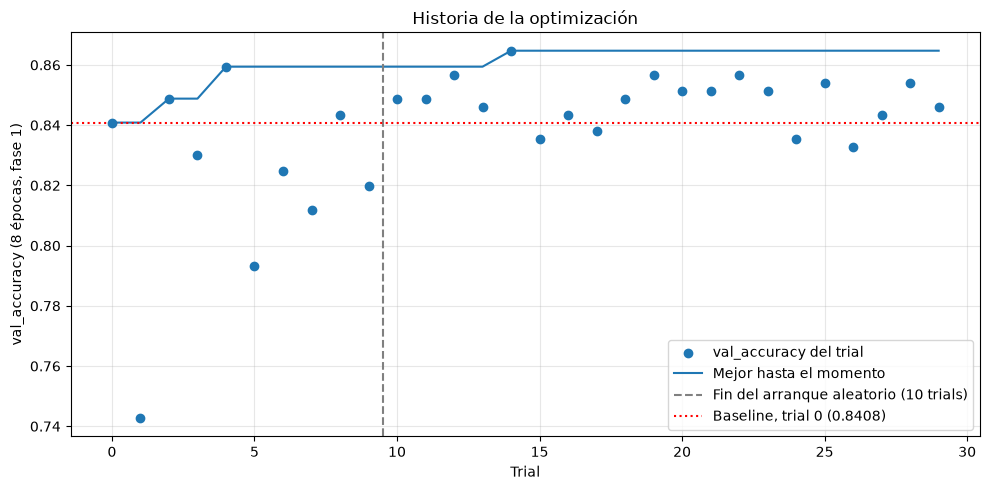

Arranque aleatorio (10 trials): media 0.8215 | máximo 0.8594
Informados por TPE (20 trials): media 0.8483 | máximo 0.8647

Mejora del TPE sobre el azar en la media: +0.0268


In [49]:
# 13b. Historia de la optimización
#      Sirve para ver si el TPE aportó algo: si los trials informados (a la derecha de
#      la línea) se concentran más arriba que los de arranque aleatorio, el sampler
#      está explotando las regiones buenas del espacio.

completos = [
    t for t in study.trials
    if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None
]

numeros = [t.number for t in completos]
valores = [t.value for t in completos]
mejor_acumulado = np.maximum.accumulate(valores)

plt.figure(figsize=(10, 5))
plt.scatter(numeros, valores, label="val_accuracy del trial", zorder=3)
plt.plot(numeros, mejor_acumulado, label="Mejor hasta el momento", zorder=2)
plt.axvline(
    OPTUNA_STARTUP_TRIALS - 0.5,
    linestyle="--",
    color="gray",
    label=f"Fin del arranque aleatorio ({OPTUNA_STARTUP_TRIALS} trials)"
)
plt.axhline(
    valor_baseline,
    linestyle=":",
    color="red",
    label=f"Baseline, trial 0 ({valor_baseline:.4f})"
)
plt.xlabel("Trial")
plt.ylabel("val_accuracy (8 épocas, fase 1)")
plt.title("Historia de la optimización")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "jer_optuna_historia.png"), dpi=120)
plt.show()

aleatorios = [t.value for t in completos if t.number < OPTUNA_STARTUP_TRIALS]
informados = [t.value for t in completos if t.number >= OPTUNA_STARTUP_TRIALS]

print(f"Arranque aleatorio ({len(aleatorios)} trials): "
      f"media {np.mean(aleatorios):.4f} | máximo {np.max(aleatorios):.4f}")

if informados:
    print(f"Informados por TPE ({len(informados)} trials): "
          f"media {np.mean(informados):.4f} | máximo {np.max(informados):.4f}")
    print(
        f"\nMejora del TPE sobre el azar en la media: "
        f"{np.mean(informados) - np.mean(aleatorios):+.4f}"
    )
else:
    print("No hubo trials informados: OPTUNA_TRIALS <= OPTUNA_STARTUP_TRIALS")

In [50]:
# 14. Tabla de todos los trials (sin pandas)
#     La columna "fuente" distingue el baseline encolado, los trials de arranque
#     aleatorio y los propuestos por el TPE.

def fuente_trial(trial):
    if trial.number == 0:
        return "baseline"
    if trial.number < OPTUNA_STARTUP_TRIALS:
        return "azar"
    return "tpe"


filas = sorted(
    study.trials,
    key=lambda t: (t.value if t.value is not None else -np.inf),
    reverse=True
)

encabezado = (
    f"{'number':>7}{'value':>10}{'fuente':>10}{'dense_units':>13}"
    f"{'dropout':>10}{'learning_rate':>16}{'optimizer':>12}{'state':>12}"
)
print(encabezado)
print("-" * len(encabezado))

for trial in filas:
    valor = f"{trial.value:.4f}" if trial.value is not None else "-"
    print(
        f"{trial.number:>7}{valor:>10}{fuente_trial(trial):>10}"
        f"{trial.params.get('dense_units', '-'):>13}"
        f"{trial.params.get('dropout_rate', float('nan')):>10.2f}"
        f"{trial.params.get('learning_rate', float('nan')):>16.8f}"
        f"{trial.params.get('optimizer', '-'):>12}"
        f"{trial.state.name:>12}"
    )

 number     value    fuente  dense_units   dropout   learning_rate   optimizer       state
------------------------------------------------------------------------------------------
     14    0.8647       tpe          256      0.30      0.00039449     rmsprop    COMPLETE
      4    0.8594      azar          256      0.35      0.00037184     rmsprop    COMPLETE
     12    0.8568       tpe           64      0.20      0.00033896        adam    COMPLETE
     19    0.8568       tpe          256      0.45      0.00049192     rmsprop    COMPLETE
     22    0.8568       tpe           64      0.30      0.00036378        adam    COMPLETE
     25    0.8541       tpe          256      0.30      0.00076625     rmsprop    COMPLETE
     28    0.8541       tpe          256      0.35      0.00028491        adam    COMPLETE
     20    0.8515       tpe          256      0.45      0.00057809     rmsprop    COMPLETE
     21    0.8515       tpe           64      0.20      0.00034326        adam    COMPLETE

In [51]:
# 15. Reentrenamiento del top-K a presupuesto completo
#
#     Aquí está el arreglo de fondo. El ranking de la búsqueda se midió con pocas épocas
#     de solo fase 1, que no es la misma pregunta que "cuál es mejor con 25+15 épocas en
#     dos fases". En vez de confiar en ese ranking, se reentrenan los TOP_K mejores con
#     el presupuesto completo y se elige con el resultado de eso.
#
#     La selección usa VALIDACIÓN. El test no se toca hasta la Parte C.

candidatos = sorted(
    [t for t in study.trials
     if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None],
    key=lambda t: t.value,
    reverse=True
)[:TOP_K]

print(f"Reentrenando los {len(candidatos)} mejores trials a presupuesto completo")
print(f"({EPOCHS_FASE1} épocas de fase 1 + {EPOCHS_FASE2} de fine-tuning cada uno)")

resultados_topk = []

for puesto, trial in enumerate(candidatos, start=1):
    print()
    print("=" * 76)
    print(
        f"[{puesto}/{len(candidatos)}] Trial {trial.number} "
        f"({fuente_trial(trial)}) — val_accuracy en la búsqueda: {trial.value:.4f}"
    )
    print(f"    {trial.params}")
    print("=" * 76)

    semilla()
    limpiar_memoria()

    model_c, optimizer_c, criterion_c = construir_modelo(
        dense_units=trial.params["dense_units"],
        dropout_rate=trial.params["dropout_rate"],
        optimizer_name=trial.params["optimizer"],
        learning_rate=trial.params["learning_rate"],
        nombre_modelo=f"candidato_trial_{trial.number}"
    )

    print("\n-- Fase 1: backbone congelado")
    h1 = entrenar(
        model_c,
        optimizer_c,
        criterion_c,
        epochs=EPOCHS_FASE1,
        patience_es=6,
        patience_lr=3,
        min_lr=1e-7,
        verbose=1
    )

    print("\n-- Fase 2: fine-tuning de los últimos 3 bloques")
    descongelar_ultimos_bloques(model_c, n_bloques=3)

    optimizer_c2 = construir_optimizador(
        model_c,
        trial.params["optimizer"],
        FINE_TUNE_LR
    )

    h2 = entrenar(
        model_c,
        optimizer_c2,
        criterion_c,
        epochs=EPOCHS_FASE2,
        patience_es=5,
        patience_lr=2,
        min_lr=1e-7,
        verbose=1
    )

    # Mejor val_accuracy de todo el run (las dos fases), que es el criterio de selección
    val_completo = max(h1["val_accuracy"] + h2["val_accuracy"])

    resultados_topk.append({
        "trial": trial.number,
        "fuente": fuente_trial(trial),
        "params": dict(trial.params),
        "val_busqueda": float(trial.value),
        "val_completo": float(val_completo),
        "history_fase1": h1,
        "history_fase2": h2,
        # a CPU para no acumular modelos en la VRAM de 4 GB
        "state_dict": {
            clave: valor.detach().cpu().clone()
            for clave, valor in model_c.state_dict().items()
        }
    })

    print(
        f"\n=> Trial {trial.number}: val_accuracy a presupuesto completo = "
        f"{val_completo:.4f} (en la búsqueda era {trial.value:.4f})"
    )

    del model_c, optimizer_c, optimizer_c2
    limpiar_memoria()

print("\nReentrenamiento del top-K terminado.")

Reentrenando los 3 mejores trials a presupuesto completo
(25 épocas de fase 1 + 15 de fine-tuning cada uno)

[1/3] Trial 14 (tpe) — val_accuracy en la búsqueda: 0.8647
    {'dense_units': 256, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.00039448805930278243, 'optimizer': 'rmsprop'}

-- Fase 1: backbone congelado
Época 01/25 | loss 0.8480 acc 0.6920 | val_loss 0.6337 val_acc 0.7586 | lr 3.94e-04
Época 02/25 | loss 0.6190 acc 0.7752 | val_loss 0.6313 val_acc 0.7347 | lr 3.94e-04
Época 03/25 | loss 0.5379 acc 0.8086 | val_loss 0.4760 val_acc 0.8355 | lr 3.94e-04
Época 04/25 | loss 0.4967 acc 0.8063 | val_loss 0.4613 val_acc 0.8355 | lr 3.94e-04
Época 05/25 | loss 0.4304 acc 0.8426 | val_loss 0.4792 val_acc 0.8329 | lr 3.94e-04
Época 06/25 | loss 0.4119 acc 0.8431 | val_loss 0.4358 val_acc 0.8435 | lr 3.94e-04
Época 07/25 | loss 0.4120 acc 0.8437 | val_loss 0.4292 val_acc 0.8382 | lr 3.94e-04
Época 08/25 | loss 0.3624 acc 0.8664 | val_loss 0.3930 val_acc 0.8647 | lr 3.94e-04
Ép

In [52]:
# 16. Selección del ganador
#     Se elige por val_accuracy a presupuesto completo, no por el valor de la búsqueda.

ranking = sorted(resultados_topk, key=lambda r: r["val_completo"], reverse=True)
ganador = ranking[0]

encabezado = (
    f"{'trial':>7}{'fuente':>10}{'val búsqueda':>15}{'val completo':>15}"
    f"{'dense':>8}{'dropout':>9}{'lr':>14}{'optimizer':>11}"
)
print("TOP-K REENTRENADO A PRESUPUESTO COMPLETO")
print(encabezado)
print("-" * len(encabezado))

for resultado in ranking:
    parametros = resultado["params"]
    print(
        f"{resultado['trial']:>7}{resultado['fuente']:>10}"
        f"{resultado['val_busqueda']:>15.4f}{resultado['val_completo']:>15.4f}"
        f"{parametros['dense_units']:>8}{parametros['dropout_rate']:>9.2f}"
        f"{parametros['learning_rate']:>14.8f}{parametros['optimizer']:>11}"
    )

orden_busqueda = [r["trial"] for r in resultados_topk]
orden_completo = [r["trial"] for r in ranking]

print()
if orden_busqueda != orden_completo:
    print("El ranking CAMBIÓ al reentrenar a presupuesto completo:")
    print(f"  por valor de búsqueda: {orden_busqueda}")
    print(f"  por presupuesto completo: {orden_completo}")
    print(
        "  -> confirma que el ranking de la búsqueda no predice bien el resultado final,\n"
        "     que es justo el motivo de reentrenar el top-K."
    )
else:
    print(f"El ranking se mantuvo: {orden_completo}")

# Reconstrucción del modelo ganador
BEST_DENSE_UNITS = ganador["params"]["dense_units"]
BEST_DROPOUT = ganador["params"]["dropout_rate"]
BEST_LR = ganador["params"]["learning_rate"]
BEST_OPTIMIZER = ganador["params"]["optimizer"]
BEST_TRIAL = ganador["trial"]

model_optuna = TrashNetMobileNetV3(BEST_DENSE_UNITS, BEST_DROPOUT).to(DEVICE)
model_optuna.load_state_dict(ganador["state_dict"])
model_optuna.nombre = "trashnet_jerarquico_optuna"

# Los pesos ya vienen entrenados; esto solo deja los flags requires_grad en el
# mismo estado en que terminó la fase 2, para que resumen_modelo() no informe el
# modelo entero como entrenable.
descongelar_ultimos_bloques(model_optuna, n_bloques=3)

# Nombres que espera la Parte C
history_optuna_fase1 = ganador["history_fase1"]
history_optuna_fase2 = ganador["history_fase2"]

print()
print("GANADOR: trial", BEST_TRIAL, f"({ganador['fuente']})")
print("Dense units:", BEST_DENSE_UNITS)
print("Dropout:", BEST_DROPOUT)
print("Learning rate:", BEST_LR)
print("Optimizer:", BEST_OPTIMIZER)
print(f"val_accuracy a presupuesto completo: {ganador['val_completo']:.4f}")

if ganador["params"] == PARAMS_BASELINE:
    print(
        "\nAVISO: el ganador ES la configuración del baseline. 'Sin Optuna' y "
        "'Con Optuna'\ncomparten hiperparámetros, así que la comparación de la Parte C "
        "mide solo la\nvarianza entre dos corridas del mismo modelo."
    )

print()
resumen_modelo(model_optuna)

TOP-K REENTRENADO A PRESUPUESTO COMPLETO
  trial    fuente   val búsqueda   val completo   dense  dropout            lr  optimizer
-----------------------------------------------------------------------------------------
     14       tpe         0.8647         0.8912     256     0.30    0.00039449    rmsprop
      4      azar         0.8594         0.8859     256     0.35    0.00037184    rmsprop
     12       tpe         0.8568         0.8700      64     0.20    0.00033896       adam

El ranking se mantuvo: [14, 4, 12]

GANADOR: trial 14 (tpe)
Dense units: 256
Dropout: 0.30000000000000004
Learning rate: 0.00039448805930278243
Optimizer: rmsprop
val_accuracy a presupuesto completo: 0.8912

Modelo: trashnet_jerarquico_optuna
Parámetros totales:     1,075,748
Parámetros entrenables: 1,075,748
Parámetros congelados:  0


In [53]:
# 17. Guardar el modelo ganador

RUTA_MODELO_OPTUNA = os.path.join(
    MODEL_DIR,
    "trashnet_jerarquico_optuna.pt"
)

torch.save(
    {
        "state_dict": model_optuna.state_dict(),
        "dense_units": BEST_DENSE_UNITS,
        "dropout_rate": BEST_DROPOUT,
        "learning_rate": BEST_LR,
        "optimizer": BEST_OPTIMIZER,
        "trial": BEST_TRIAL,
        "val_accuracy": ganador["val_completo"],
        "classes": CLASSES,
        "mapeo": MAPEO_NOMBRE,
        "img_size": IMG_SIZE
    },
    RUTA_MODELO_OPTUNA
)

print("Modelo con Optuna guardado en:", RUTA_MODELO_OPTUNA)

Modelo con Optuna guardado en: modelos/trashnet_jerarquico_optuna.pt


## Parte C — Evaluación y comparación definitiva

A partir de aquí no se vuelve a entrenar y es la **primera vez que se toca el conjunto
de test**: toda la selección de hiperparámetros se hizo con validación. Se evalúan el
modelo de la Parte A (baseline) y el ganador de la Parte B sobre el mismo test,
manteniendo `shuffle=False` para conservar el orden de las etiquetas.

Las métricas están implementadas a mano con NumPy porque el entorno no tiene
scikit-learn. Son las mismas funciones del notebook de 6 clases: son genéricas en el
número de clases, así que funcionan igual con 4.

In [54]:
# 18. Métricas manuales (sin scikit-learn)

def obtener_predicciones(model, loader):
    """Devuelve (y_true, y_pred, y_prob) con las probabilidades softmax."""
    model.eval()

    y_true_all, y_prob_all = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            probs = torch.softmax(model(images), dim=1).cpu().numpy()
            y_true_all.append(labels.numpy())
            y_prob_all.append(probs)

    y_true = np.concatenate(y_true_all)
    y_prob = np.concatenate(y_prob_all)

    return y_true, np.argmax(y_prob, axis=1), y_prob


def confusion_matrix(y_true, y_pred, n=N_CLASSES):
    cm = np.zeros((n, n), dtype=int)
    for real, predicho in zip(y_true, y_pred):
        cm[real][predicho] += 1
    return cm


def metricas_por_clase(cm):
    """precision, recall, f1 y support por clase, a partir de la matriz de confusión."""
    metricas = {}

    for i in range(len(cm)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        soporte = cm[i, :].sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0.0
        )

        metricas[i] = {
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "support": int(soporte)
        }

    return metricas


def accuracy_score(y_true, y_pred):
    return float((np.asarray(y_true) == np.asarray(y_pred)).mean())


def macro(metricas, clave):
    return float(np.mean([m[clave] for m in metricas.values()]))


def roc_curve(y_true_bin, y_score):
    """
    ROC one-vs-rest recorriendo todos los umbrales presentes en y_score.
    AUC por regla del trapecio.
    """
    umbrales = np.sort(np.unique(y_score))[::-1]

    P = int(y_true_bin.sum())
    N = len(y_true_bin) - P

    if P == 0 or N == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 1.0]), 0.5

    fprs, tprs = [0.0], [0.0]

    for umbral in umbrales:
        pred = (y_score >= umbral).astype(int)
        tp = int(((pred == 1) & (y_true_bin == 1)).sum())
        fp = int(((pred == 1) & (y_true_bin == 0)).sum())
        fprs.append(fp / N)
        tprs.append(tp / P)

    fprs.append(1.0)
    tprs.append(1.0)

    fpr, tpr = np.array(fprs), np.array(tprs)

    # numpy >= 2 renombró np.trapz a np.trapezoid
    _trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

    return fpr, tpr, abs(float(_trapz(tpr, fpr)))


def label_binarize(y, n_clases=N_CLASSES):
    return np.eye(n_clases, dtype=int)[np.asarray(y)]


def roc_auc_macro(y_true, y_prob, n_clases=N_CLASSES):
    """Macro-average AUC one-vs-rest, equivalente a roc_auc_score(multi_class='ovr')."""
    y_bin = label_binarize(y_true, n_clases)
    aucs = [roc_curve(y_bin[:, i], y_prob[:, i])[2] for i in range(n_clases)]
    return float(np.mean(aucs))


def classification_report(y_true, y_pred, target_names=CLASSES, digits=4):
    """Reporte con el mismo formato que sklearn.metrics.classification_report."""
    cm = confusion_matrix(y_true, y_pred, len(target_names))
    metricas = metricas_por_clase(cm)
    total = int(cm.sum())

    ancho = max(len(nombre) for nombre in target_names) + 2
    cabecera = (
        f"{'':>{ancho}}{'precision':>12}{'recall':>12}"
        f"{'f1-score':>12}{'support':>12}"
    )
    lineas = [cabecera, ""]

    for i, nombre in enumerate(target_names):
        m = metricas[i]
        lineas.append(
            f"{nombre:>{ancho}}"
            f"{m['precision']:>12.{digits}f}"
            f"{m['recall']:>12.{digits}f}"
            f"{m['f1']:>12.{digits}f}"
            f"{m['support']:>12d}"
        )

    lineas.append("")
    lineas.append(
        f"{'accuracy':>{ancho}}{'':>12}{'':>12}"
        f"{accuracy_score(y_true, y_pred):>12.{digits}f}{total:>12d}"
    )
    lineas.append(
        f"{'macro avg':>{ancho}}"
        f"{macro(metricas, 'precision'):>12.{digits}f}"
        f"{macro(metricas, 'recall'):>12.{digits}f}"
        f"{macro(metricas, 'f1'):>12.{digits}f}"
        f"{total:>12d}"
    )

    pesos = np.array([metricas[i]["support"] for i in range(len(target_names))])
    ponderada = {
        clave: float(
            np.average([metricas[i][clave] for i in range(len(target_names))], weights=pesos)
        )
        for clave in ("precision", "recall", "f1")
    }
    lineas.append(
        f"{'weighted avg':>{ancho}}"
        f"{ponderada['precision']:>12.{digits}f}"
        f"{ponderada['recall']:>12.{digits}f}"
        f"{ponderada['f1']:>12.{digits}f}"
        f"{total:>12d}"
    )

    return "\n".join(lineas)

In [55]:
# 19. Etiquetas reales y probabilidades de ambos modelos

y_true, y_pred_base, y_prob_base = obtener_predicciones(model_base, test_loader)
_, y_pred_optuna, y_prob_optuna = obtener_predicciones(model_optuna, test_loader)

print("Cantidad de observaciones:", len(y_true))
print("Forma probabilidades sin Optuna:", y_prob_base.shape)
print("Forma probabilidades con Optuna:", y_prob_optuna.shape)

Cantidad de observaciones: 384
Forma probabilidades sin Optuna: (384, 4)
Forma probabilidades con Optuna: (384, 4)


In [56]:
# 20. Métricas generales comparativas

def calcular_metricas(y_real, y_pred, y_prob):
    cm = confusion_matrix(y_real, y_pred)
    por_clase = metricas_por_clase(cm)

    return {
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision macro": macro(por_clase, "precision"),
        "Recall macro": macro(por_clase, "recall"),
        "F1 macro": macro(por_clase, "f1"),
        "ROC AUC macro OVR": roc_auc_macro(y_real, y_prob)
    }

metricas_base = calcular_metricas(y_true, y_pred_base, y_prob_base)
metricas_optuna = calcular_metricas(y_true, y_pred_optuna, y_prob_optuna)

nombres_metricas = list(metricas_base.keys())
ancho = max(len(nombre) for nombre in nombres_metricas) + 2

print(f"{'':<{ancho}}{'Sin Optuna':>14}{'Con Optuna':>14}")
for nombre in nombres_metricas:
    print(
        f"{nombre:<{ancho}}"
        f"{metricas_base[nombre]:>14.4f}"
        f"{metricas_optuna[nombre]:>14.4f}"
    )

print(f"\nAccuracy sin Optuna: {metricas_base['Accuracy']:.2%}")
print(f"Accuracy con Optuna: {metricas_optuna['Accuracy']:.2%}")

diferencia = metricas_optuna["Accuracy"] - metricas_base["Accuracy"]

print(f"Diferencia de accuracy: {diferencia:+.2%}")

                       Sin Optuna    Con Optuna
Accuracy                   0.8724        0.8880
Precision macro            0.8115        0.8270
Recall macro               0.8532        0.8762
F1 macro                   0.8281        0.8461
ROC AUC macro OVR          0.9764        0.9768

Accuracy sin Optuna: 87.24%
Accuracy con Optuna: 88.80%
Diferencia de accuracy: +1.56%


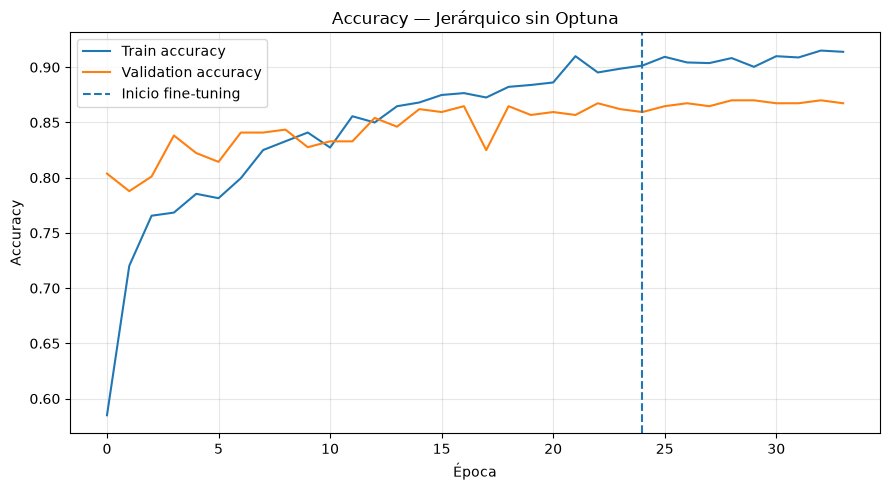

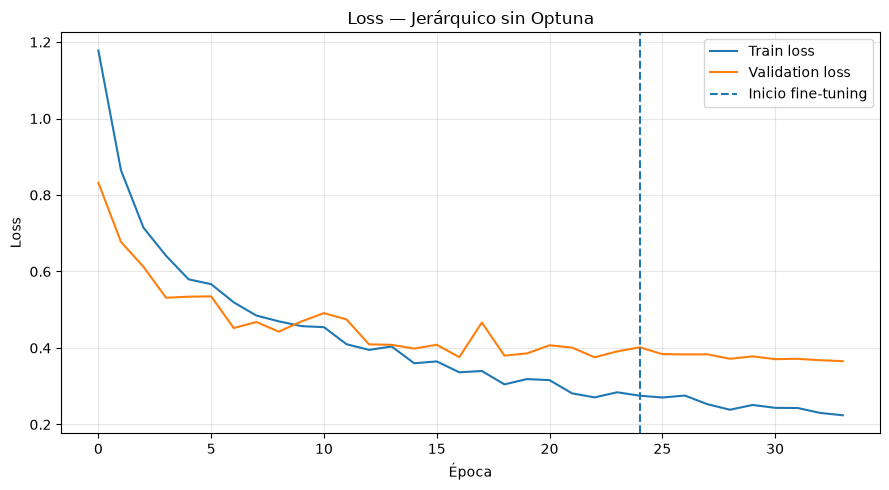

In [57]:
# 21. Curvas de entrenamiento: modelo sin Optuna

def unir_historiales(history_fase1, history_fase2):
    resultado = {}

    for metrica in ["accuracy", "val_accuracy", "loss", "val_loss"]:
        resultado[metrica] = history_fase1[metrica] + history_fase2[metrica]

    resultado["inicio_fine_tuning"] = len(history_fase1["accuracy"])

    return resultado


def graficar_curvas(hist, titulo_sufijo, archivo=None):
    for metrica, etiqueta in [("accuracy", "Accuracy"), ("loss", "Loss")]:
        plt.figure(figsize=(9, 5))
        plt.plot(hist[metrica], label=f"Train {metrica}")
        plt.plot(hist[f"val_{metrica}"], label=f"Validation {metrica}")
        plt.axvline(
            hist["inicio_fine_tuning"] - 1,
            linestyle="--",
            label="Inicio fine-tuning"
        )
        plt.title(f"{etiqueta} — {titulo_sufijo}")
        plt.xlabel("Época")
        plt.ylabel(etiqueta)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()

        if archivo:
            plt.savefig(
                os.path.join(RESULTS_DIR, f"{archivo}_{metrica}.png"),
                dpi=120
            )

        plt.show()


hist_base = unir_historiales(history_base_fase1, history_base_fase2)

graficar_curvas(hist_base, "Jerárquico sin Optuna", "jer_curvas_sin_optuna")

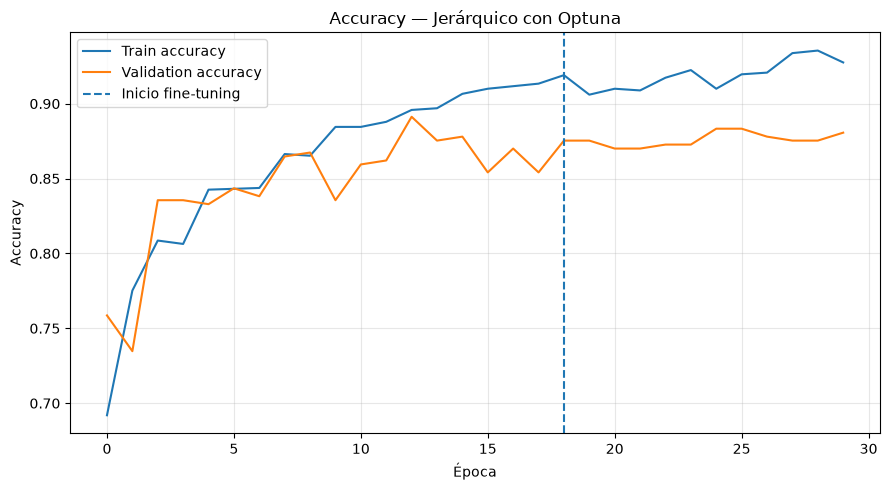

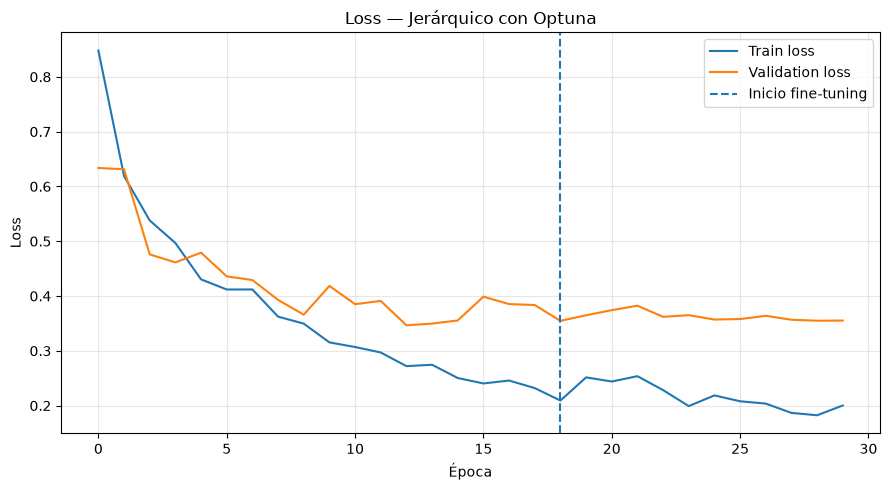

In [58]:
# 22. Curvas de entrenamiento: modelo con Optuna

hist_optuna = unir_historiales(history_optuna_fase1, history_optuna_fase2)

graficar_curvas(hist_optuna, "Jerárquico con Optuna", "jer_curvas_optuna")

In [59]:
# 23. Reportes de clasificación

print("=" * 70)
print("REPORTE DE CLASIFICACIÓN — SIN OPTUNA")
print("=" * 70)
print(classification_report(y_true, y_pred_base, CLASSES, digits=4))

print()
print("=" * 70)
print("REPORTE DE CLASIFICACIÓN — CON OPTUNA")
print("=" * 70)
print(classification_report(y_true, y_pred_optuna, CLASSES, digits=4))

REPORTE DE CLASIFICACIÓN — SIN OPTUNA
             precision      recall    f1-score     support

  amarillo      0.8712      0.8519      0.8614         135
      azul      0.9589      0.9272      0.9428         151
      gris      0.6000      0.8182      0.6923          22
     verde      0.8158      0.8158      0.8158          76

  accuracy                              0.8724         384
 macro avg      0.8115      0.8532      0.8281         384
weighted avg      0.8792      0.8724      0.8747         384

REPORTE DE CLASIFICACIÓN — CON OPTUNA
             precision      recall    f1-score     support

  amarillo      0.8846      0.8519      0.8679         135
      azul      0.9795      0.9470      0.9630         151
      gris      0.6129      0.8636      0.7170          22
     verde      0.8312      0.8421      0.8366          76

  accuracy                              0.8880         384
 macro avg      0.8270      0.8762      0.8461         384
weighted avg      0.8958      0.

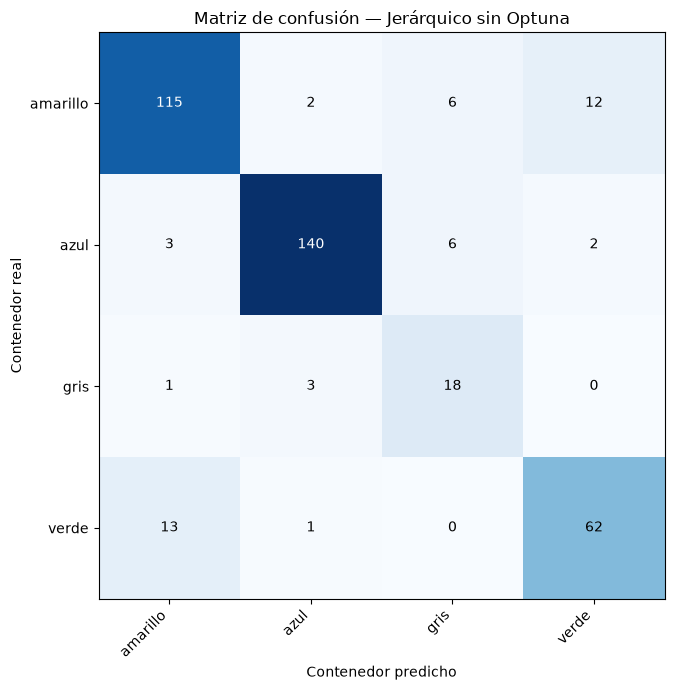

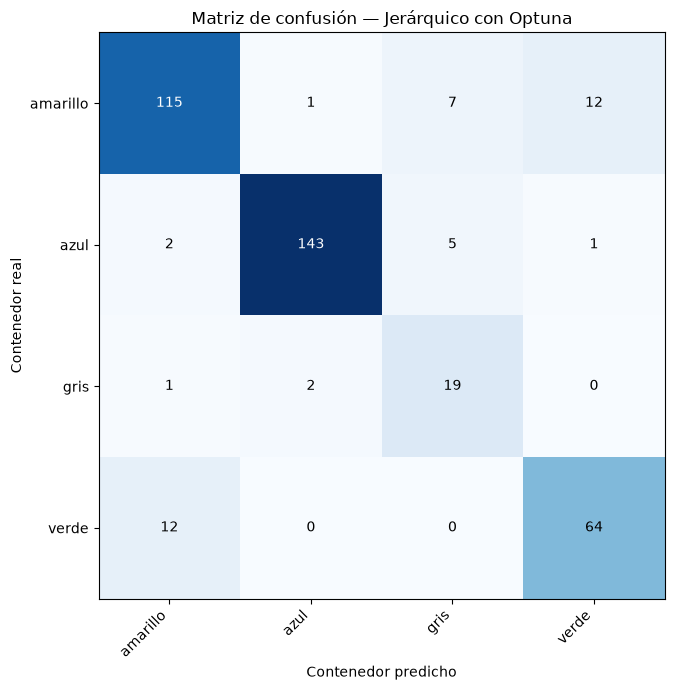

In [60]:
# 24. Matrices de confusión

cm_base = confusion_matrix(y_true, y_pred_base)
cm_optuna = confusion_matrix(y_true, y_pred_optuna)


def graficar_matriz_confusion(cm, titulo, archivo=None):
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.imshow(cm, interpolation="nearest", cmap="Blues")

    ax.set_xticks(np.arange(N_CLASSES))
    ax.set_yticks(np.arange(N_CLASSES))
    ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Contenedor predicho")
    ax.set_ylabel("Contenedor real")

    umbral = cm.max() / 2.0
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(
                j, i, f"{cm[i, j]:d}",
                ha="center", va="center",
                color="white" if cm[i, j] > umbral else "black"
            )

    plt.title(titulo)
    plt.tight_layout()

    if archivo:
        plt.savefig(os.path.join(RESULTS_DIR, archivo), dpi=120)

    plt.show()


graficar_matriz_confusion(
    cm_base,
    "Matriz de confusión — Jerárquico sin Optuna",
    "jer_matriz_confusion_sin_optuna.png"
)

graficar_matriz_confusion(
    cm_optuna,
    "Matriz de confusión — Jerárquico con Optuna",
    "jer_matriz_confusion_optuna.png"
)

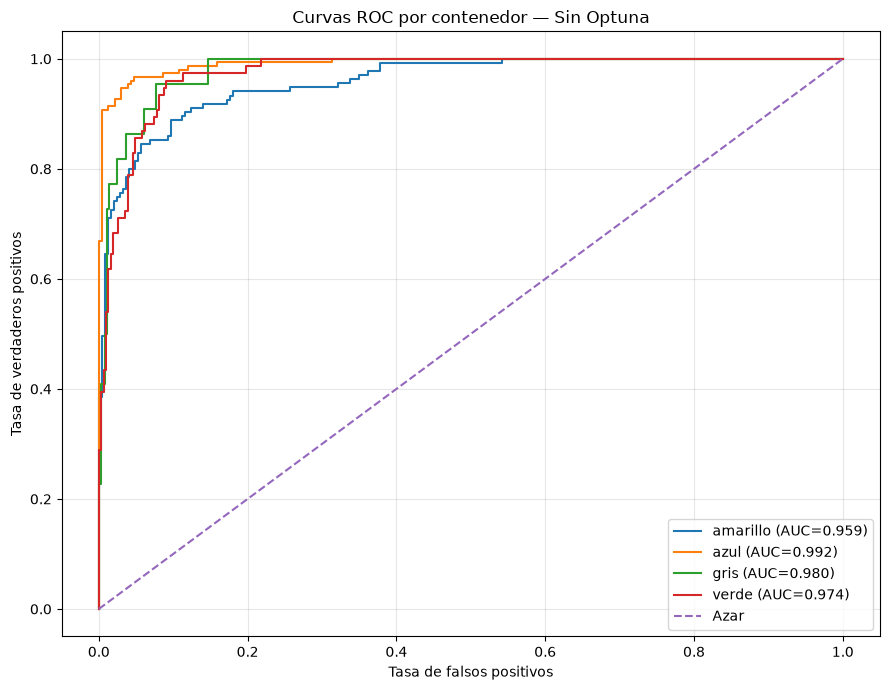

In [61]:
# 25. Curvas ROC por clase — Sin Optuna

y_true_bin = label_binarize(y_true, N_CLASSES)


def graficar_roc_por_clase(y_bin, y_prob, titulo, archivo=None):
    plt.figure(figsize=(9, 7))

    aucs = {}

    for i, clase in enumerate(CLASSES):
        fpr, tpr, roc_auc = roc_curve(y_bin[:, i], y_prob[:, i])
        aucs[clase] = roc_auc

        plt.plot(fpr, tpr, label=f"{clase} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
    plt.xlabel("Tasa de falsos positivos")
    plt.ylabel("Tasa de verdaderos positivos")
    plt.title(titulo)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if archivo:
        plt.savefig(os.path.join(RESULTS_DIR, archivo), dpi=120)

    plt.show()

    return aucs


auc_clases_base = graficar_roc_por_clase(
    y_true_bin,
    y_prob_base,
    "Curvas ROC por contenedor — Sin Optuna",
    "jer_roc_sin_optuna.png"
)

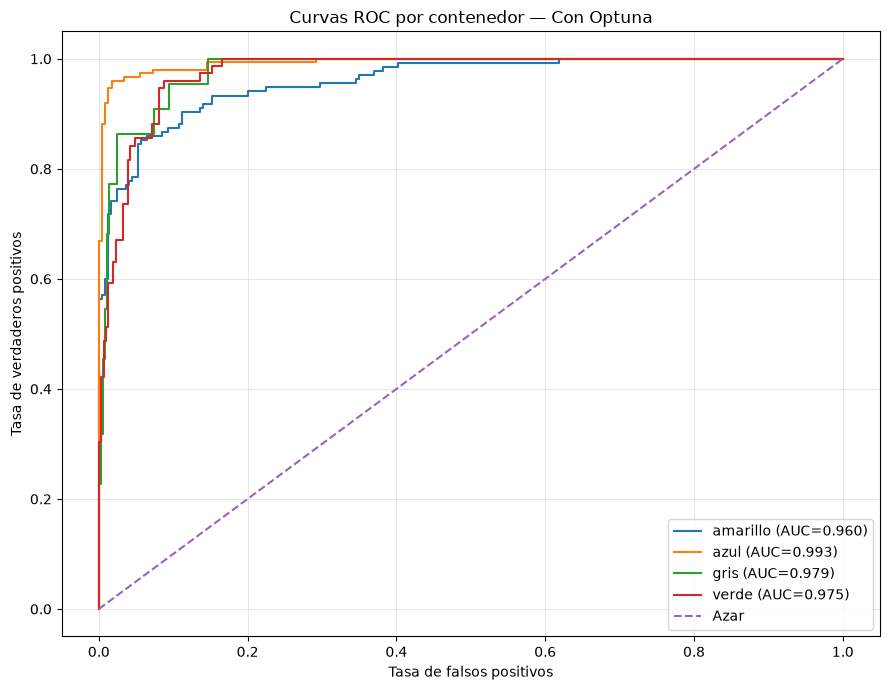

In [62]:
# 26. Curvas ROC por clase — Con Optuna

auc_clases_optuna = graficar_roc_por_clase(
    y_true_bin,
    y_prob_optuna,
    "Curvas ROC por contenedor — Con Optuna",
    "jer_roc_optuna.png"
)

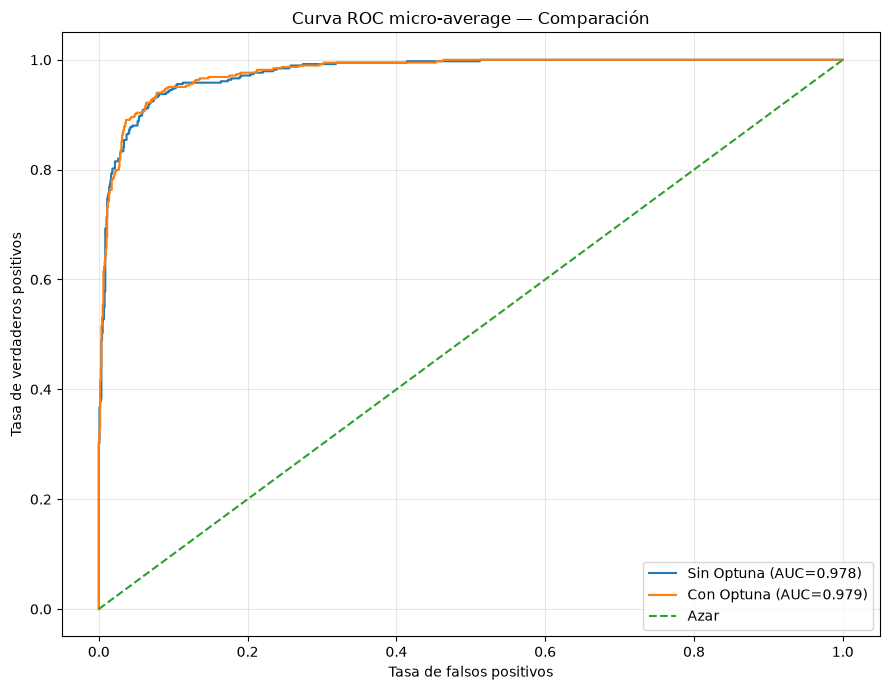

In [63]:
# 27. Comparación ROC micro-average

fpr_base_micro, tpr_base_micro, auc_base_micro = roc_curve(
    y_true_bin.ravel(),
    y_prob_base.ravel()
)

fpr_optuna_micro, tpr_optuna_micro, auc_optuna_micro = roc_curve(
    y_true_bin.ravel(),
    y_prob_optuna.ravel()
)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr_base_micro,
    tpr_base_micro,
    label=f"Sin Optuna (AUC={auc_base_micro:.3f})"
)

plt.plot(
    fpr_optuna_micro,
    tpr_optuna_micro,
    label=f"Con Optuna (AUC={auc_optuna_micro:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC micro-average — Comparación")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "jer_roc_micro_comparacion.png"), dpi=120)
plt.show()

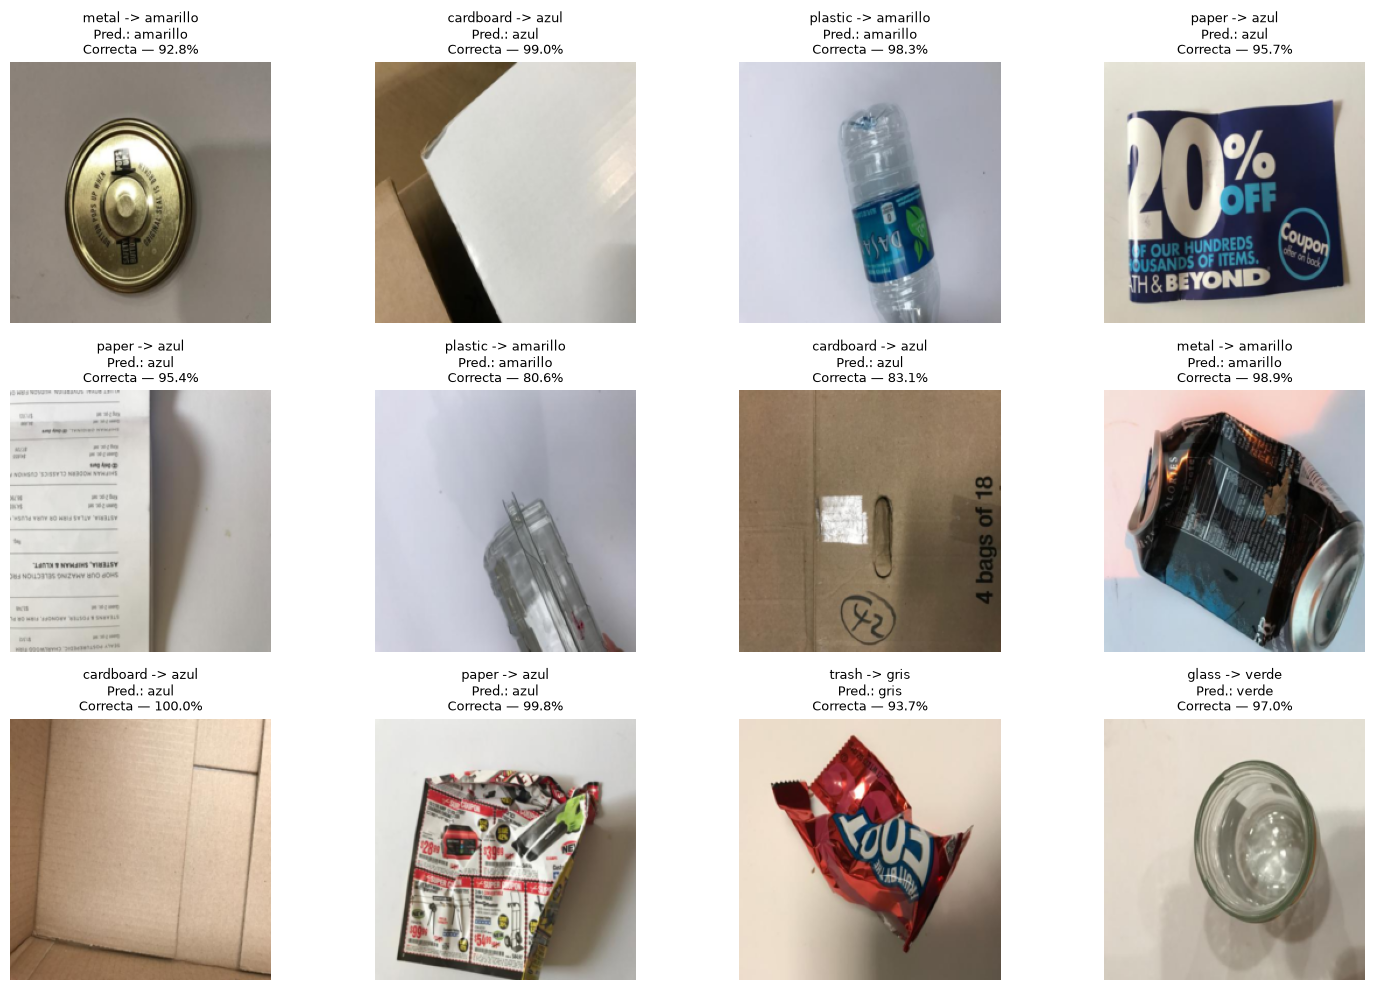

In [64]:
# 28. Predicciones aleatorias del modelo con Optuna
#     Se muestra el material original y el contenedor, para que se vea el agrupamiento.

# Dataset paralelo sin normalizar, solo para mostrar las imágenes. Comparte el mismo
# orden que test_ds, así que los índices sirven para los dos. Aquí NO se remapea la
# etiqueta: se quiere el material original para el título.
test_ds_vis = datasets.ImageFolder(
    TEST_DIR,
    transform=transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor()
    ])
)

rng = np.random.default_rng(SEED)
indices = rng.choice(
    len(test_ds),
    size=min(12, len(test_ds)),
    replace=False
)

lote = torch.stack([test_ds[i][0] for i in indices]).to(DEVICE)

model_optuna.eval()
with torch.no_grad():
    selected_prob = torch.softmax(model_optuna(lote), dim=1).cpu().numpy()

plt.figure(figsize=(15, 10))

for posicion, indice in enumerate(indices):
    imagen, material_index = test_ds_vis[indice]
    true_index = ORIGINAL_TO_CONTAINER[material_index]
    pred_index = int(np.argmax(selected_prob[posicion]))
    confidence = float(selected_prob[posicion][pred_index])

    plt.subplot(3, 4, posicion + 1)
    plt.imshow(imagen.permute(1, 2, 0).numpy())

    estado = "Correcta" if true_index == pred_index else "Incorrecta"

    plt.title(
        f"{ORIGINAL_CLASSES[material_index]} -> {CLASSES[true_index]}\n"
        f"Pred.: {CLASSES[pred_index]}\n"
        f"{estado} — {confidence:.1%}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "jer_predicciones_optuna.png"), dpi=120)
plt.show()

In [65]:
# 29. Resumen final imprimible

print("=" * 76)
print("RESUMEN FINAL — TRASHNET JERÁRQUICO POR CONTENEDOR (PYTORCH)")
print("=" * 76)

print("\nDATASET")
print(f"- Train: {sum(train_count.values())} imágenes")
print(f"- Validation: {sum(valid_count.values())} imágenes")
print(f"- Test: {sum(test_count.values())} imágenes")
print(f"- Clases finales: {N_CLASSES}")
print(f"- Tamaño de entrada: {IMG_SIZE}")
print(f"- Batch size: {BATCH_SIZE}")
print(f"- Dispositivo: {DEVICE}")

print("\nCLASES / CONTENEDORES")
for i, clase in enumerate(CLASSES):
    print(f"- {i}: {clase}")

print("\nAGRUPACIÓN UTILIZADA")
print("- Amarillo: plástico + metal")
print("- Azul: papel + cartón")
print("- Gris: basura")
print("- Verde: vidrio")

print("\nMODELO SIN OPTUNA (baseline, Parte A)")
print(f"- Dense units: {BASE_DENSE_UNITS}")
print(f"- Dropout: {BASE_DROPOUT}")
print(f"- Learning rate fase 1: {BASE_LR}")
print(f"- Optimizador: {BASE_OPTIMIZER}")
print(f"- Accuracy test: {metricas_base['Accuracy']:.2%}")
print(f"- Precision macro: {metricas_base['Precision macro']:.2%}")
print(f"- Recall macro: {metricas_base['Recall macro']:.2%}")
print(f"- F1 macro: {metricas_base['F1 macro']:.2%}")
print(f"- ROC AUC macro OVR: {metricas_base['ROC AUC macro OVR']:.4f}")

print("\nBÚSQUEDA CON OPTUNA")
print(f"- Trials: {OPTUNA_TRIALS} "
      f"({OPTUNA_STARTUP_TRIALS} de azar + {OPTUNA_TRIALS - OPTUNA_STARTUP_TRIALS} TPE)")
print(f"- Épocas por trial: {OPTUNA_EPOCHS} (solo fase 1)")
print(f"- Baseline encolado como trial 0: val_accuracy {valor_baseline:.4f}")
print(f"- Mejor trial de la búsqueda: {study.best_trial.number} "
      f"(val_accuracy {study.best_value:.4f})")
print(f"- Top-{TOP_K} reentrenado a presupuesto completo: "
      f"{[r['trial'] for r in resultados_topk]}")
print(f"- Ganador tras el reentrenamiento: trial {BEST_TRIAL} ({ganador['fuente']})")

if BEST_TRIAL != study.best_trial.number:
    print("  OJO: el ganador NO es el mejor trial de la búsqueda; el ranking cambió")
    print("  al usar el presupuesto completo.")

print("\nMODELO CON OPTUNA")
print(f"- Dense units: {BEST_DENSE_UNITS}")
print(f"- Dropout: {BEST_DROPOUT}")
print(f"- Learning rate fase 1: {BEST_LR:.8f}")
print(f"- Optimizador: {BEST_OPTIMIZER}")
print(f"- val_accuracy a presupuesto completo: {ganador['val_completo']:.2%}")
print(f"- Accuracy test: {metricas_optuna['Accuracy']:.2%}")
print(f"- Precision macro: {metricas_optuna['Precision macro']:.2%}")
print(f"- Recall macro: {metricas_optuna['Recall macro']:.2%}")
print(f"- F1 macro: {metricas_optuna['F1 macro']:.2%}")
print(f"- ROC AUC macro OVR: {metricas_optuna['ROC AUC macro OVR']:.4f}")

print("\nCOMPARACIÓN")
print(f"- Diferencia de accuracy: {diferencia:+.2%}")
print(f"- Diferencia en imágenes: {round(diferencia * len(y_true)):+d} de {len(y_true)}")
print(f"- AUC micro sin Optuna: {auc_base_micro:.4f}")
print(f"- AUC micro con Optuna: {auc_optuna_micro:.4f}")

mejor_modelo = (
    "Con Optuna"
    if metricas_optuna["Accuracy"] > metricas_base["Accuracy"]
    else "Sin Optuna"
    if metricas_optuna["Accuracy"] < metricas_base["Accuracy"]
    else "Empate"
)

print(f"- Mejor accuracy en test: {mejor_modelo}")

if ganador["params"] == PARAMS_BASELINE:
    print("- Los dos modelos comparten hiperparámetros: la diferencia es solo ruido")
    print("  entre corridas y sirve para medir el piso de ruido del experimento.")

print("\nAUC POR CONTENEDOR (con Optuna)")
for clase, valor in auc_clases_optuna.items():
    print(f"- {clase:<10}: {valor:.4f}")

print("\nARCHIVOS")
print(f"- Modelo sin Optuna: {RUTA_MODELO_BASE}")
print(f"- Modelo con Optuna: {RUTA_MODELO_OPTUNA}")
print(f"- Figuras: {RESULTS_DIR}/jer_*.png")
print("=" * 76)

RESUMEN FINAL — TRASHNET JERÁRQUICO POR CONTENEDOR (PYTORCH)

DATASET
- Train: 1766 imágenes
- Validation: 377 imágenes
- Test: 384 imágenes
- Clases finales: 4
- Tamaño de entrada: (224, 224)
- Batch size: 32
- Dispositivo: cuda

CLASES / CONTENEDORES
- 0: amarillo
- 1: azul
- 2: gris
- 3: verde

AGRUPACIÓN UTILIZADA
- Amarillo: plástico + metal
- Azul: papel + cartón
- Gris: basura
- Verde: vidrio

MODELO SIN OPTUNA (baseline, Parte A)
- Dense units: 128
- Dropout: 0.35
- Learning rate fase 1: 0.0003
- Optimizador: adam
- Accuracy test: 87.24%
- Precision macro: 81.15%
- Recall macro: 85.32%
- F1 macro: 82.81%
- ROC AUC macro OVR: 0.9764

BÚSQUEDA CON OPTUNA
- Trials: 30 (10 de azar + 20 TPE)
- Épocas por trial: 8 (solo fase 1)
- Baseline encolado como trial 0: val_accuracy 0.8408
- Mejor trial de la búsqueda: 14 (val_accuracy 0.8647)
- Top-3 reentrenado a presupuesto completo: [14, 4, 12]
- Ganador tras el reentrenamiento: trial 14 (tpe)

MODELO CON OPTUNA
- Dense units: 256
- Dropo

In [66]:
# 30. Referencia: resultados del mismo modelo en TensorFlow
#     Copiados del resumen de tensorflow/TrashNet_TensorFlow_Jerarquico_DEFINITIVO.ipynb
#     para tener la comparación entre frameworks a mano en el informe.

TF_JERARQUICO = {
    "Sin Optuna": {
        "Accuracy": 0.8568,
        "Precision macro": 0.8152,
        "Recall macro": 0.8036,
        "F1 macro": 0.8050,
        "ROC AUC macro OVR": 0.9716
    },
    "Con Optuna": {
        "Accuracy": 0.8594,
        "Precision macro": 0.8498,
        "Recall macro": 0.7870,
        "F1 macro": 0.8068,
        "ROC AUC macro OVR": 0.9741
    }
}

PYTORCH_JERARQUICO = {
    "Sin Optuna": metricas_base,
    "Con Optuna": metricas_optuna
}

ancho = 20
print("COMPARACIÓN ENTRE FRAMEWORKS — MODELO JERÁRQUICO")
print()

for variante in ["Sin Optuna", "Con Optuna"]:
    print(variante.upper())
    print(f"{'':<{ancho}}{'TensorFlow':>14}{'PyTorch':>14}{'Dif.':>10}")

    for metrica, valor_tf in TF_JERARQUICO[variante].items():
        valor_pt = PYTORCH_JERARQUICO[variante][metrica]
        print(
            f"{metrica:<{ancho}}"
            f"{valor_tf:>14.4f}"
            f"{valor_pt:>14.4f}"
            f"{valor_pt - valor_tf:>+10.4f}"
        )

    print()

print(
    "NOTA: el modelo y el protocolo de entrenamiento son los mismos en los dos\n"
    "frameworks, así que la fila 'Sin Optuna' es una comparación directa. La fila\n"
    "'Con Optuna' NO lo es: TensorFlow usa 10 trials (random search de hecho) y se\n"
    "queda con study.best_params, mientras aquí van 30 trials con el baseline\n"
    "encolado y selección por reentrenamiento del top-3."
)

COMPARACIÓN ENTRE FRAMEWORKS — MODELO JERÁRQUICO

SIN OPTUNA
                        TensorFlow       PyTorch      Dif.
Accuracy                    0.8568        0.8724   +0.0156
Precision macro             0.8152        0.8115   -0.0037
Recall macro                0.8036        0.8532   +0.0496
F1 macro                    0.8050        0.8281   +0.0231
ROC AUC macro OVR           0.9716        0.9764   +0.0048

CON OPTUNA
                        TensorFlow       PyTorch      Dif.
Accuracy                    0.8594        0.8880   +0.0286
Precision macro             0.8498        0.8270   -0.0228
Recall macro                0.7870        0.8762   +0.0892
F1 macro                    0.8068        0.8461   +0.0393
ROC AUC macro OVR           0.9741        0.9768   +0.0027

NOTA: el modelo y el protocolo de entrenamiento son los mismos en los dos
frameworks, así que la fila 'Sin Optuna' es una comparación directa. La fila
'Con Optuna' NO lo es: TensorFlow usa 10 trials (random search de h

## Interpretación final

La predicción de este modelo es el **contenedor recomendado**, no el material original:

| Material original | Contenedor |
|---|---|
| Plástico | Amarillo |
| Metal | Amarillo |
| Papel | Azul |
| Cartón | Azul |
| Vidrio | Verde |
| Trash / rechazo | Gris |

Una imagen de `paper` y una de `cardboard` tienen la misma etiqueta final: `azul`.

### Qué mirar al analizar los resultados

1. **Cuánto ayuda realmente el reagrupamiento.** Juntar `metal` + `plastic` en
   `amarillo` elimina dos de las tres direcciones de la confusión
   glass ↔ plastic ↔ metal que domina el modelo de 6 clases. Si el accuracy sube poco
   respecto a ese modelo, significa que el error que queda es casi todo **vidrio
   confundido con el contenedor amarillo**, y ninguna agrupación por contenedor puede
   arreglar eso.
2. **`gris` es la clase frágil.** Solo 95 imágenes de train y 22 de test: un acierto o
   fallo mueve su recall 4,5 puntos. Su `class_weight` de 4,65 la compensa en la loss,
   pero cualquier métrica por clase sobre `gris` hay que leerla con cuidado. El patrón
   esperable es recall alto con precision baja: el modelo la usa como cajón de sastre.
3. **Cuánto de la diferencia es señal y cuánto es ruido.** Con 384 imágenes de test, un
   punto de accuracy son ~4 imágenes. Antes de afirmar que un modelo es mejor que otro,
   hay que comparar la diferencia contra el piso de ruido del experimento: en la primera
   versión de este notebook, la misma configuración dio val_accuracy 0.8727 durante la
   búsqueda y 0.8568 al reentrenarla, **1,6 puntos de diferencia por puro estado del
   RNG**. Cualquier diferencia de ese orden no distingue nada. `semilla()` en cada trial
   reduce ese ruido, pero no lo elimina: sigue habiendo una sola semilla por
   configuración.
4. **Qué aportó Optuna de verdad.** Con la búsqueda corregida hay tres cosas distintas
   que mirar, y conviene reportarlas por separado:
   - si los trials informados por el TPE superan en media a los de arranque aleatorio
     (celda 13b), que es lo único que mide si la búsqueda *bayesiana* sirvió;
   - si el mejor trial le gana al baseline encolado **en la métrica de búsqueda**;
   - si ese ganador sigue ganando **a presupuesto completo** (celda 16), que es la
     pregunta que de verdad importa.
   Perfectamente pueden salir respuestas distintas para las tres, y ese contraste es más
   interesante para el informe que un único número de accuracy.